# **<span style="color:orange;">Quest 19: Encrypted Duck</span>**

![Header image](./imgs/image_quest_19.svg)
[<img src="./imgs/instagram.svg" alt="My SVG" width="15" height="15"><small>_Monika Lipińska_</small>](https://www.instagram.com/monli_art/)

---

## <span style="color:orange;">Part I</span>

> ### :book: Story section
>
> During the Tournament, the Order of the Golden Duck has opened its catacombs for exploration by contestants. As you navigate through narrow corridors, you come across a large chamber, well-lit by sunlight streaming in through small windows at its peak. In the center lies a stone tomb with a plaque in front of it:
>
> <pre style="border: solid grey 1px;border-radius:1px;padding:2px;text-align: center;">= Sir Enigmatus Encriptus =
> 
> Devised a method to communicate without the risk 
> of message interception by messengers or 
> enemies during the Great RAM (Realm Allocation Mayhem) War
> 
> </pre>
>
> Around the tomb, there are many books placed on pedestals. You check a few of them. In addition to the descriptions of the heroic deeds and accomplishments of the Golden Duck Order, you also find a book describing the method of message encryption. It turns out to be very simple yet clever!
> <br/><br/>

The message is hidden on a grid of characters. <span style="color:Ivory">To read the message, you need to perform a sequence of rotations on every rotation point on the grid according to the message key.</span>

To start, you need to understand the concept of a rotation point. Each cell on the grid has neighboring cells (including diagonals). The number of neighboring cells depends on whether the cell is in the corner (3 neighboring cells), on the edge (5 neighboring cells), or elsewhere (8 neighboring cells). <span style="color:Ivory">A rotation point is a cell that has 8 neighboring cells.</span> Example rotation points on a grid are marked with `R` below, and their neighboring cells are marked with `N `:

The edge of the farm has exactly one cell marked as part of the channel: `.`</span>. This is where <span style="color:Ivory">the water will enter the farm. Every minute the water spreads to all adjacent channel segments vertically and horizontally.</span> The segments with palm trees are at the same level as the channel, and water can flow through them just like a regular channel segment.

<pre style="border: solid grey 1px;border-radius:1px;padding:4px;width:fit-content">
NNN..     .....     .....     .....
N<span style="color:Ivory">R</span>N..     .....     NNN..     .NNN.
NNN..     ..NNN     N<span style="color:Ivory">R</span>N..     .N<span style="color:Ivory">R</span>N.
.....     ..N<span style="color:Ivory">R</span>N     NNN..     .NNN.
.....     ..NNN     .....     .....
</pre>

To untangle the hidden message, you need to <span style="color:Ivory">rotate the 8 cells surrounding each rotation point to the left or right according to the message key.</span> Start from the top leftmost rotation point, continuing through all the rotation points to the right on the same row, then proceed to the following row, moving from left to right. Repeat this process until you reach the final rotation point on the bottom right. Note that the border cells are not rotation points, as they do not have 8 surrounding neighboring cells.

Below you can see the correct order for processing all <span style="color:Ivory">9 rotation points</span> on the sample 5x5 grid:

<pre style="border: solid grey 1px;border-radius:1px;padding:4px;width:fit-content">
NNN..     .NNN.     ..NNN     .....     .....     .....     .....     .....     .....
N<span style="color:Ivory">R</span>N..     .N<span style="color:Ivory">R</span>N.     ..N<span style="color:Ivory">R</span>N     NNN..     .NNN.     ..NNN     .....     .....     .....
NNN..     .NNN.     ..NNN     N<span style="color:Ivory">R</span>N..     .N<span style="color:Ivory">R</span>N.     ..N<span style="color:Ivory">R</span>N     NNN..     .NNN.     ..NNN
.....     .....     .....     NNN..     .NNN.     ..NNN     N<span style="color:Ivory">R</span>N..     .N<span style="color:Ivory">R</span>N.     ..N<span style="color:Ivory">R</span>N
.....     .....     .....     .....     .....     .....     NNN..     .NNN.     ..NNN
</pre>

There are 2 possible operations that can be performed on rotation points:

- R - rotate neighboring cells by one item clockwise:

```
        ABC     HAB
        HxD  >  GxC
        GFE     FED
```

- L - rotate neighboring cells by one item counterclockwise:

```
        ABC     BCD
        HxD  >  AxE
        GFE     HGF
```

<span style="color:Ivory">The message key contains a sequence of `R` and `L` operations that should be performed on all rotation points</span> on the message grid. If the key is shorter than the number of operations required, you simply repeat the key as many times as necessary.

<span style="color:Ivory">The final message always starts after the `>` and ends before the `<` characters.</span> These characters are always unique within the grid.

You decide to practice decoding a sample message from the book ( <span style="color:yellow">your notes</span> ), just for fun.

<span style="color:Ivory">Example based on the following notes:</span>

<pre style="width:fit-content;border: dashed green;border-radius:5px;padding:2px;">
LR

>-IN-
-----
W---<
</pre>

The first line contains the message key: `LR`. You can repeat it as many times as needed, so in fact it looks like this: ` LRLRLRLRLR...` . The rest of the input is separated by an empty line and represents the hidden message.

To read the message, you need to perform the key operations sequence on the message grid. The sample grid is small, so there are only 3 rotation points. Below you can see the sequence of operations with the rotation points highlighted:

<pre style="border: solid grey 1px;border-radius:1px;padding:4px;width:fit-content">
 
 >-IN-    -I-N-    --I--    -----    -----
 -----    ><span style="color:lightgreen">-</span>---    >W<span style="color:lightgreen">-</span>N-    >WI<span style="color:lightgreen">N</span><    >WIN< 
 W---<    -W--<    ----<    -----    -----

 start      L        R        L       end
 </pre>

You can confirm that decoding is successful, because `>` and `<` are in the same line.
In the example above the hidden message is <span style="color:Ivory">WIN</span> .

<span style="color:Yellow">What is the message hidden in the example you are analyzing?</span>


In [1]:
import re
from collections.abc import Iterator
from itertools import product

from tabulate import tabulate
from test_utilities import test
from util import Str, hexcolor_str

rotation_tests = [
    {
        'name': 'R  - rotate neighboring cells by one item clockwise',
        'notes': """
            R

            ABC
            HxD
            GFE
        """,
        'expected': """
            HAB
            GxC
            FED
        """,
    },
    {
        'name': 'L  - rotate neighboring cells by one item counterclockwise:',
        'notes': """
            L
            ABC
            HxD
            GFE
        """,
        'expected': """
            BCD
            AxE
            HGF
        """,
    },
]

type Point = tuple[int, int]

INF = 10**18


class Decryptor(Str):
    NEIGHBORS = (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1)

    def __init__(self, notes: str) -> None:
        key, *message = re.findall(r'\S+', notes)
        self.key = key
        self.message = [list(line) for line in message]
        self.rotation_points = self.get_rotation_points()

    def get_message(self) -> str:
        for line in self.message:
            if (
                (ids := [i for i, ch in enumerate(line) if ch in '><'])
                and len(ids) == 2
                and line[ids[0]] == '>'
                and line[ids[1]] == '<'
            ):
                return ''.join(line[ids[0] + 1 : ids[1]])

        raise ValueError('No valid line found!')

    def decrypt(self, max_rotations: int = INF, debug: bool = False) -> None:
        if debug:
            print(self)
            print()
            print('start')
            print()

        i = 0

        while i == 0 or (
            i < max_rotations
            and not any(line[0] == '>' and line[-1] == '<' for line in self.message)
        ):
            opr = self.key[i % len(self.key)]
            r_r, r_c = self.rotation_points[i % len(self.rotation_points)]

            if opr == 'R':
                self.rotate_right(r_r, r_c)
            else:
                self.rotate_left(r_r, r_c)

            if debug:
                print(self.debug(r_r, r_c))
                print()
                print(f'{opr}')
                print()

            i += 1

    def rotate_left(self, r: int, c: int) -> None:
        dr, dc = self.NEIGHBORS[0]
        temp = self.message[r + dr][c + dc]

        for dr, dc in reversed(self.NEIGHBORS):
            self.message[r + dr][c + dc], temp = temp, self.message[r + dr][c + dc]

    def rotate_right(self, r: int, c: int) -> None:
        dr, dc = self.NEIGHBORS[-1]
        temp = self.message[r + dr][c + dc]

        for dr, dc in self.NEIGHBORS:
            self.message[r + dr][c + dc], temp = temp, self.message[r + dr][c + dc]

    def get_rotation_points(self) -> list[Point]:
        rows, cols = len(self.message), len(self.message[0])

        return [
            (r, c)
            for r, c in product(range(rows), range(cols))
            if sum(1 for _ in self.valid_neighbors(r, c)) == 8
        ]

    def valid_neighbors(self, r: int, c: int) -> Iterator[Point]:
        rows, cols = len(self.message), len(self.message[0])

        for dr, dc in self.NEIGHBORS:
            if 0 <= r + dr < rows and 0 <= c + dc < cols:
                yield r + dr, c + dc

    def debug(self, row: int, col: int) -> str:
        rows, cols = len(self.message), len(self.message[0])

        return tabulate(
            [
                [
                    hexcolor_str('#00FF00', self.message[r][c])
                    if (r, c) == (row, col)
                    else self.message[r][c]
                    for c in range(cols)
                ]
                for r in range(rows)
            ],
            tablefmt='rounded_grid',
        )

    def __str__(self) -> str:
        return '\n'.join(''.join(line) for line in self.message)


def assert_function(a: str, e: str) -> bool:
    e = '\n'.join(re.findall(r'\S+', e))
    return a == e


@test(tests=rotation_tests[:], assert_fun=assert_function)
def rotation_test(notes: str) -> str:
    d = Decryptor(notes)
    d.decrypt(1)
    return str(d)



Test R  - rotate neighboring cells by one item clockwise passed, for rotation_test.
Test L  - rotate neighboring cells by one item counterclockwise: passed, for rotation_test.
Success


In [2]:
tests = [
    {
        'name': 'Example Part I',
        'notes': """
                LR

                >-IN-
                -----
                W---<
        """,
        'expected': 'WIN',
    },
]


@test(tests=tests[:])
def part_I(notes: str) -> str:
    d = Decryptor(notes)
    d.decrypt(debug=False)
    return d.get_message()


Test Example Part I passed, for part_I.
Success


In [3]:
with open('../inputs/everybody_codes_e2024_q19_p1.txt') as f:
    notes1 = f.read()

print(f'Part I: {part_I(notes1)}')

Part I: 8596335288797441


## <span style="color:orange">Part II</span>

Of course, that was only an example showing the basic idea. The real messages had additional, misleading symbols which made the decoding process much more difficult. Additionally, processing the message according to the key only once was deemed insufficient, as it could be easily decoded by enemies.

Standard messages assumed that the <span style="color:ivory;">operations for the whole message needed to be repeated <samp style="border: 1px dashed orange;border-radius:1px;padding:1px 1em 1px;">100</samp> times.</span> Each time you start from the top left rotation point and from the beginning of the message key sequence.

You find another riddle in the book ( <span style="color:yellow">your notes</span> ), where the hidden message is the number of potions used by Sir Enigmatus Encriptus during the battle with the HTML (Hulking Tapestry Mighty Leviathan).

<span style="color:Ivory">Example based on the following notes:</span>

<pre style="width:fit-content;border: dashed green;border-radius:5px;padding:2px;">
RRLL

A.VI..>...T
.CC...<...O
.....EIB.R.
.DHB...YF..
.....F..G..
D.H........
</pre>

Below you can see all the rotation points highlighted for a single round of operations. You must visit them in order, from left to right and row by row, from top to bottom.

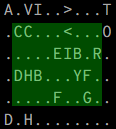

Result after 1 round of operations:

<pre style="width:fit-content;border:solid grey 1px;border-radius:1px;padding:2px;">
.C...E.....
..IB...YFB.
.A..V...>TO
.CH....I...
.D.....FR..
D.<.H..G...
</pre>

Results after 2, 3, 4, and 5 rounds:

<div style="display:grid;gap:1em;grid-template-columns:0 repeat(4, 10em);">
<div style="width:0"></div>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
..C.V..F>.B
A....B.I..Y
.....E.F...
.I&ltD.......
.D...HG.T..
C...H.OR...
</pre>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
A....EB....
...D..F..FI
....C.G..BY
V..D..O....
.C..>HRH...
I...<..T...
</pre>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
....C.....F
...D.D.....
.A...ERHB.I
...C...G...
VI...<THB..
..F>..Y.O..
</pre>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
.....ED.B..
A..C.D.G.H.
......TH.F.
C.FI..YR...
..>V...<...
......IB.O.
</pre>

</div>
Results after 97, 98, 99, and 100 rounds:
<div style="display:grid;gap:1em;grid-template-columns:0 repeat(4, 10em);">
<div style="width:0"></div>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
.....IECBV..
..&gt......YF
.A.....I.O.
C.R.B.&lt.F..
D..D.......
..T.G...HH.
</pre>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
..........Y
A...B.B.FI.
...D.E..C.F
I&gtT........
C..DVG..OH.
....R...&ltH.
</pre>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
A..B.E.FC.I
...........
...D.....Y.
....D...H..
I..C.R.G.H.
&gt.BVT.FO.&lt.
</pre>

<pre style="border:solid grey 1px;border-radius:1px;padding:2px;;width:fit-content;">
...........
..B.D.F.H..
.A.C.E.G.I.
..B.D.F.H..
.&gtVICTORY&lt.
...........
</pre>

</div>

In the example above, the hidden message is <span style="color:ivory;weight:bolder">VICTORY</span>.

<span style="color:yellow">Decode your message. What is the number of potions used by Sir Enigmatus Encriptus during the battle with the HTML?</span>


In [4]:
tests = [
    {
        'name': 'Notes Part II',
        'notes': """
            RRLL

            A.VI..>...T
            .CC...<...O
            .....EIB.R.
            .DHB...YF..
            .....F..G..
            D.H........
        """,
        'expected': 'VICTORY',
    },
]


class DecryptorII(Decryptor):
    def decrypt(self, rounds: int, debug: bool = False) -> None:
        if debug:
            print(self)
            print()
            print('start')
            print()

        for _ in range(rounds):
            self.decrypt_one_round(debug=debug)

    def decrypt_one_round(self, debug: bool = False):
        for i, (r_r, r_c) in enumerate(self.rotation_points):
            opr = self.key[i % len(self.key)]

            if opr == 'R':
                self.rotate_right(r_r, r_c)
            else:
                self.rotate_left(r_r, r_c)

        if debug:
            print(self.debug(r_r, r_c))
            print()
            print(f'{opr}')
            print()


@test(tests=tests[:])
def part_II(notes: str, rounds: int = 100) -> str:
    d = DecryptorII(notes)
    d.decrypt(rounds=rounds, debug=False)
    return d.get_message()


Test Notes Part II passed, for part_II.
Success


In [5]:
with open('../inputs/everybody_codes_e2024_q19_p2.txt') as f:
    notes2 = f.read()

print(f'Part II: {part_II(notes2)}')

Part II: 4238672344841683


## <span style="color:orange">Part III</span>

The guard notices how adept you are with the arcane code and asks if you would like to try your hand at the official test. Every knight of the Order must pass it, so why not take this opportunity?

The test involves deciphering another message written by Sir Enigmatus Encriptus from when he was on a reconnaissance mission and had to count the number of knights on Little Ending Island preparing legions for a huge invasion!

The Order agreed to use <samp style="border: 1px dashed orange;border-radius:1px;padding:1px 1em 1px;">1048576000</samp> rounds of operations instead of the regular 100 for such important messages!

There is no way to do this by hand in a reasonable time; however, you have decoded the previous message, so <span style="color:ivory">you have something to experiment with.</span>

<span style="color:yellow">Decode your message. What was the number of knights on Little Ending Island?</span>


In [ ]:
tests = [
    {
        'name': 'Notes Part II',
        'notes': """
            RRLL

            A.VI..>...T
            .CC...<...O
            .....EIB.R.
            .DHB...YF..
            .....F..G..
            D.H........
        """,
        'rounds': 100,
        'expected': 'VICTORY',
    },
    {
        'name': 'Challenge Part II',
        'notes': notes2,
        'rounds': 100,
        'expected': '4238672344841683',
    },
]


class DecryptorIII(DecryptorII):
    """https://youtu.be/MpKG6FmcIHk"""

    def decrypt(self, rounds: int) -> None:
        cycles = self.find_cycles()
        rows, cols = len(self.message), len(self.message[0])

        message = [[None] * cols for _ in range(rows)]

        for cycle in cycles:
            for i, (r, c) in enumerate(cycle):
                r1, c1 = cycle[(i + rounds) % len(cycle)]
                message[r1][c1] = self.message[r][c]

        self.message = message

    def find_cycles(self):
        rows, cols = len(self.message), len(self.message[0])
        transition = self.create_transition_dict()

        cycles = []
        seen = set()

        for point in product(range(rows), range(cols)):
            if point in seen:
                continue

            cycle = []

            while point not in seen:
                cycle.append(point)
                seen.add(point)
                point = transition[point]

            cycles.append(cycle)

        return cycles

    def create_transition_dict(self) -> dict[Point, Point]:
        rows, cols = len(self.message), len(self.message[0])

        M = [[(r, c) for c in range(cols)] for r in range(rows)]

        temp = self.message
        self.message = M
        self.decrypt_one_round()
        self.message = temp

        return {M[r][c]: (r, c) for r in range(rows) for c in range(cols)}


@test(tests=tests[:])
def part_III(notes: str, rounds: int) -> str:
    d = DecryptorIII(notes)
    d.decrypt(rounds)
    return d.get_message()


Test Notes Part II passed, for part_III.
Test Challenge Part II passed, for part_III.
Success


In [7]:
with open('../inputs/everybody_codes_e2024_q19_p3.txt') as f:
    notes3 = f.read()

print(f'Part III: {part_III(notes3, 1048576000)}')

Part III: 4341698296792517


![happy](./imgs/happy_quack.svg)
